Loading and splitting data...
Found 2152 files belonging to 3 classes.
Using 1722 files for training.
Found 2152 files belonging to 3 classes.
Using 430 files for validation.
Classes found: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


C:\Users\gaura\AppData\Local\Temp\ipykernel_31688\1401248022.py:71: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = base_model_class(


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step

--- Training Custom_CNN ---
Epoch 1/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 31s 542ms/step - accuracy: 0.4791 - loss: 0.9203 - val_accuracy: 0.5243 - val_loss: 0.8337
Epoch 2/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 28s 522ms/step - accuracy: 0.6028 - loss: 0.8119 - val_accuracy: 0.5777 - val_loss: 0.8623
Epoch 3/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 30s 564ms/step - accuracy: 0.7485 - loss: 0.6348 - val_accuracy: 0.7524 - val_loss: 0.5322
Epoch 4/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 28s 518ms/step - accuracy: 0.8571 - loss: 0.4241 - val_accuracy: 0.8204 - val_loss: 0.4094
Epoch 5/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 26s 478ms/step - accuracy: 0.8815 - loss: 0.3038 - val_accuracy: 0.7621 - val_loss: 0.6557
Epoch 6/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 30s 562ms/step - accuracy: 0.8798 - loss: 0.2937 - val_accuracy: 0.6748 - val_loss: 0.9050
Epoch 7/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 32s 590ms/step - accuracy: 0.9077 - loss: 0.2448 - val_accuracy: 0.8350 - val_loss: 0.3467
Epoch 8/30
54/54 

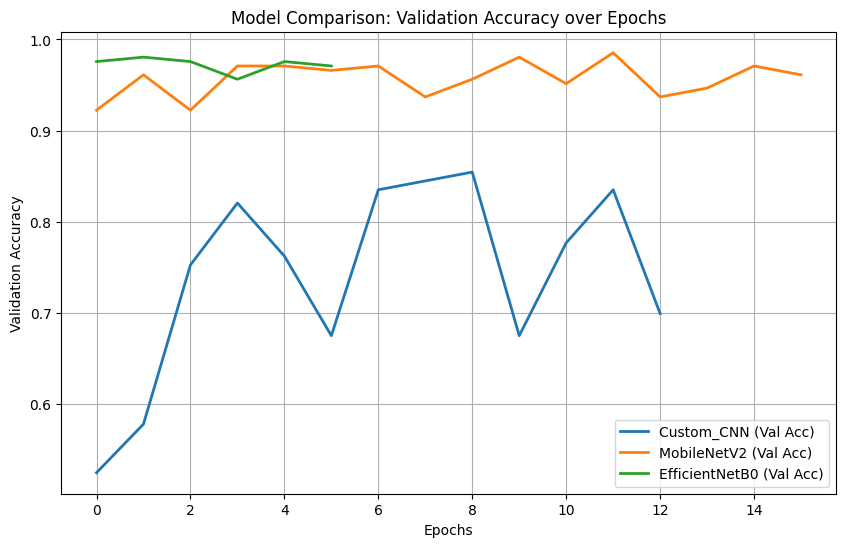

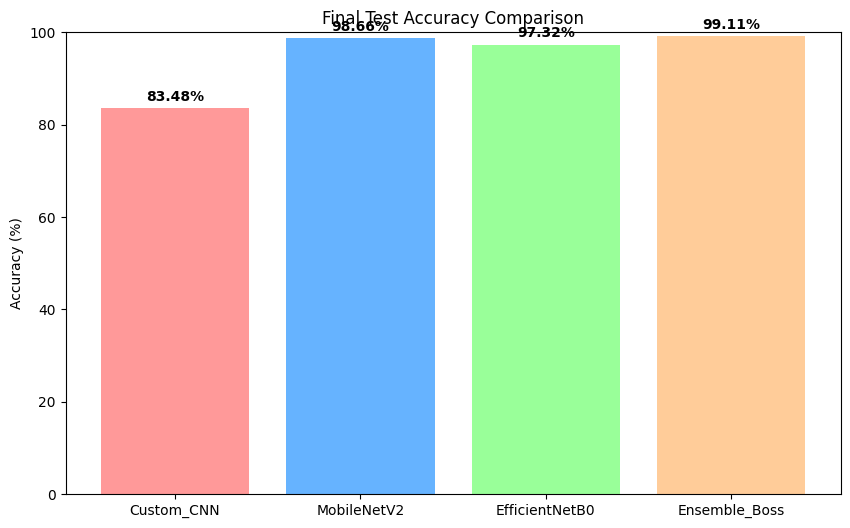

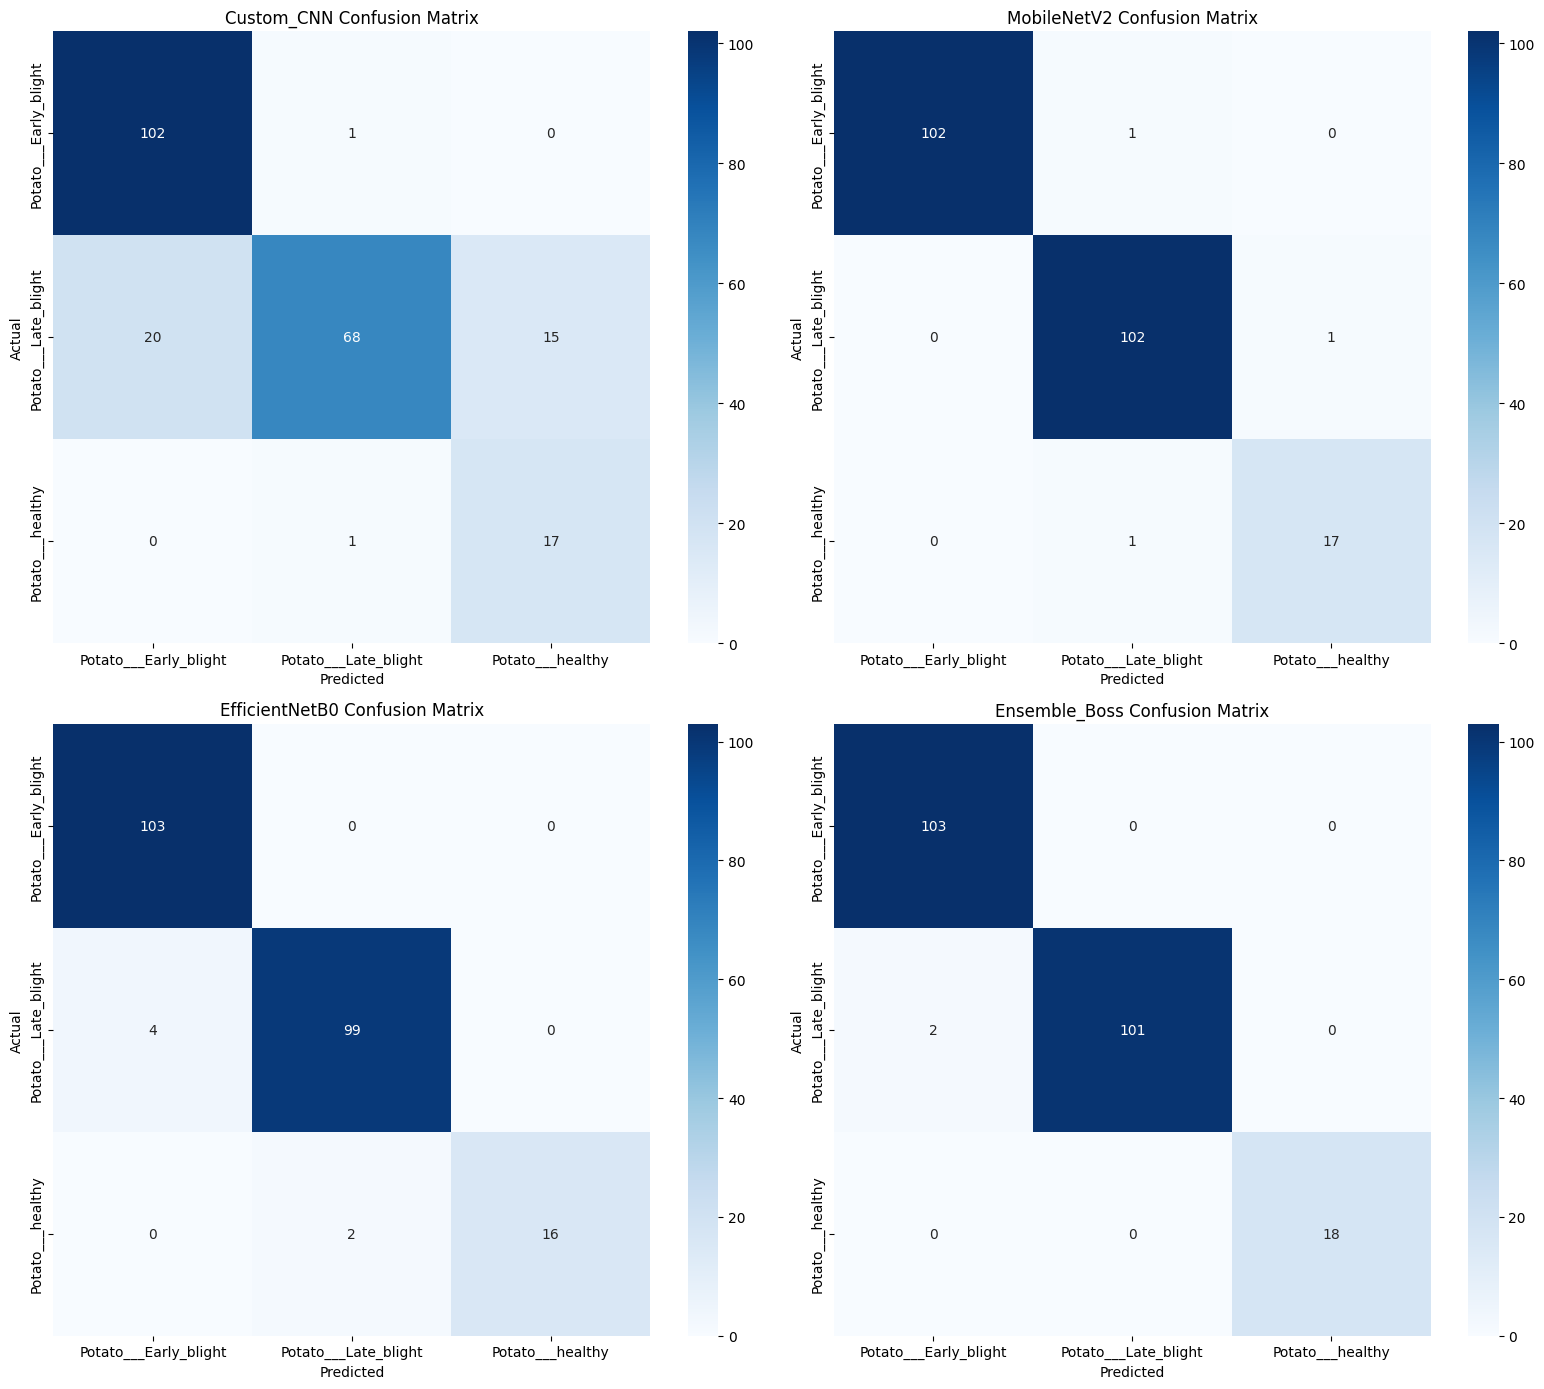


Generating Detailed Classification Reports...
--- Custom_CNN ---
                       precision    recall  f1-score   support

Potato___Early_blight       0.84      0.99      0.91       103
 Potato___Late_blight       0.97      0.66      0.79       103
     Potato___healthy       0.53      0.94      0.68        18

             accuracy                           0.83       224
            macro avg       0.78      0.86      0.79       224
         weighted avg       0.87      0.83      0.83       224

--- MobileNetV2 ---
                       precision    recall  f1-score   support

Potato___Early_blight       1.00      0.99      1.00       103
 Potato___Late_blight       0.98      0.99      0.99       103
     Potato___healthy       0.94      0.94      0.94        18

             accuracy                           0.99       224
            macro avg       0.98      0.98      0.98       224
         weighted avg       0.99      0.99      0.99       224

--- EfficientNetB0 ---
   

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, applications
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# --- 1. Configuration ---
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 30 
DATA_DIR = "PlantVillage"
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- 2. Robust Data Loading & Splitting ---
print("Loading and splitting data...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="training", seed=123,
    image_size=(IMAGE_SIZE, IMAGE_SIZE), batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="validation", seed=123,
    image_size=(IMAGE_SIZE, IMAGE_SIZE), batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
n_classes = len(class_names)
print(f"Classes found: {class_names}")

val_batches = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take(val_batches // 2)
val_ds = val_ds.skip(val_batches // 2)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
# Note: DO NOT shuffle test_ds, we need the labels to line up exactly for evaluation
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# --- 3. Shared Augmentation ---
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1)
])

# --- 4. Model Builders ---
def build_custom_cnn():
    model = models.Sequential([
        layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)),
        layers.Rescaling(1./255),
        data_augmentation,
        layers.Conv2D(32, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(n_classes, activation='softmax')
    ], name="Custom_CNN")
    return model

def build_transfer_model(base_model_class, name):
    base_model = base_model_class(
        input_shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS),
        include_top=False, weights='imagenet'
    )
    base_model.trainable = False 
    
    model = models.Sequential([
        layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)),
        layers.Rescaling(1./255) if name == "MobileNetV2" else layers.Activation('linear'),
        data_augmentation,
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(n_classes, activation='softmax')
    ], name=name)
    return model

# --- 5. Train the Models & Track History ---
model_dict = {
    "Custom_CNN": build_custom_cnn(),
    "MobileNetV2": build_transfer_model(applications.MobileNetV2, "MobileNetV2"),
    "EfficientNetB0": build_transfer_model(applications.EfficientNetB0, "EfficientNetB0")
}

trained_models = {}
model_histories = {}

for name, model in model_dict.items():
    print(f"\n--- Training {name} ---")
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    callbacks_list = [
        callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
        callbacks.ModelCheckpoint(f"{OUTPUT_DIR}/{name}_best.keras", monitor='val_accuracy', save_best_only=True)
    ]
    
    history = model.fit(
        train_ds, epochs=EPOCHS, validation_data=val_ds,
        callbacks=callbacks_list, verbose=1
    )
    trained_models[name] = model
    model_histories[name] = history.history

# --- 6. Extract Test Data & Get All Predictions ---
print("\n--- Running Predictions on Test Set ---")
# Extract actual true labels directly from the dataset
y_true = np.concatenate([y for x, y in test_ds], axis=0)

all_predictions = {}

# Get predictions for each base model
for name, model in trained_models.items():
    print(f"Gathering predictions for {name}...")
    # Predict returns the probability array (confidence scores)
    all_predictions[name] = model.predict(test_ds)

# Generate Ensemble predictions (Average the probabilities)
print("Gathering predictions for Ensemble Boss...")
all_predictions["Ensemble_Boss"] = np.mean([all_predictions["Custom_CNN"], 
                                            all_predictions["MobileNetV2"], 
                                            all_predictions["EfficientNetB0"]], axis=0)

# --- 7. VISUALIZATION & COMPARISONS ---

# A. Comparative Learning Curves (Validation Accuracy)
plt.figure(figsize=(10, 6))
for name, history in model_histories.items():
    plt.plot(history['val_accuracy'], label=f'{name} (Val Acc)', linewidth=2)
plt.title('Model Comparison: Validation Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.savefig(f"{OUTPUT_DIR}/comparative_learning_curves.png", dpi=300, bbox_inches='tight')
plt.show()

# B. Calculate Final Accuracies & Plot Bar Chart
accuracies = {}
for name, preds in all_predictions.items():
    # Convert probabilities to actual class labels (0, 1, 2, etc.)
    y_pred_labels = np.argmax(preds, axis=1)
    accuracies[name] = accuracy_score(y_true, y_pred_labels) * 100

plt.figure(figsize=(10, 6))
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'] # Custom colors
bars = plt.bar(accuracies.keys(), accuracies.values(), color=colors)
plt.title('Final Test Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)

# Add percentage text on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{round(yval, 2)}%', ha='center', va='bottom', fontweight='bold')

plt.savefig(f"{OUTPUT_DIR}/accuracy_comparison_bar.png", dpi=300, bbox_inches='tight')
plt.show()

# C. 2x2 Confusion Matrix Grid
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, (name, preds) in enumerate(all_predictions.items()):
    y_pred_labels = np.argmax(preds, axis=1)
    cm = confusion_matrix(y_true, y_pred_labels)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names, ax=axes[idx])
    axes[idx].set_title(f'{name} Confusion Matrix')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix_grid.png", dpi=300, bbox_inches='tight')
plt.show()

# D. Generate and Save Comprehensive Metrics Report
print("\nGenerating Detailed Classification Reports...")
with open(f"{OUTPUT_DIR}/comprehensive_metrics.txt", "w") as f:
    f.write("=== PLANT DISEASE CLASSIFICATION COMPARISON ===\n\n")
    
    for name, preds in all_predictions.items():
        y_pred_labels = np.argmax(preds, axis=1)
        report = classification_report(y_true, y_pred_labels, target_names=class_names)
        
        # Print to console
        print(f"--- {name} ---")
        print(report)
        
        # Write to file
        f.write(f"================ {name.upper()} ================\n")
        f.write(f"Overall Accuracy: {round(accuracies[name], 2)}%\n")
        f.write(report)
        f.write("\n\n")

print(f"\nAll visualizations and metrics have been saved to the '{OUTPUT_DIR}' directory!")